# Bitcoin Market Sentiment vs Trader Performance Analysis

## Data Science Hiring Assignment

### Objective

The objective of this project is to analyze the relationship between Bitcoin market sentiment (Fear & Greed Index) and trader performance using Hyperliquid historical trading data.

The analysis aims to identify how different market sentiments influence trading behavior and profitability, providing insights that can support better trading decisions.

In [1]:
# ==========================================
# Import Required Libraries
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from scipy.stats import ttest_ind

pd.set_option("display.max_columns", None)

plt.style.use("ggplot")

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# ==========================================
# Load Datasets
# ==========================================

trades = pd.read_csv("data/historical_data.csv")
sentiment = pd.read_csv("data/fear_greed_index.csv")

print("Trading Dataset Shape :", trades.shape)
print("Sentiment Dataset Shape :", sentiment.shape)

Trading Dataset Shape : (211224, 16)
Sentiment Dataset Shape : (2644, 4)


In [3]:
# ==========================================
# Preview Trading Dataset
# ==========================================

trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [4]:
# ==========================================
# Preview Sentiment Dataset
# ==========================================

sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


## Dataset Overview

In [5]:
# ==========================================
# Dataset Information
# ==========================================

print("Trading Dataset Information")
trades.info()

print("\n")

print("Sentiment Dataset Information")
sentiment.info()

Trading Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  str    
 1   Coin              211224 non-null  str    
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  str    
 6   Timestamp IST     211224 non-null  str    
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  str    
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  str    
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: 

In [6]:
# ==========================================
# Missing Values
# ==========================================

print("Trading Dataset Missing Values")
display(trades.isnull().sum())

print("\n")

print("Sentiment Dataset Missing Values")
display(sentiment.isnull().sum())

Trading Dataset Missing Values


Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64



Sentiment Dataset Missing Values


timestamp         0
value             0
classification    0
date              0
dtype: int64

In [7]:
# ==========================================
# Duplicate Rows
# ==========================================

print("Duplicate Rows in Trading Dataset :", trades.duplicated().sum())

print("Duplicate Rows in Sentiment Dataset :", sentiment.duplicated().sum())

Duplicate Rows in Trading Dataset : 0
Duplicate Rows in Sentiment Dataset : 0


## Data Cleaning

In [8]:
# ==========================================
# Convert Date Columns
# ==========================================

trades["Timestamp IST"] = pd.to_datetime(
    trades["Timestamp IST"],
    format="%d-%m-%Y %H:%M",
    errors="coerce"
)

trades["Date"] = trades["Timestamp IST"].dt.date

sentiment["date"] = pd.to_datetime(sentiment["date"])

sentiment["Date"] = sentiment["date"].dt.date

print("Date conversion completed successfully.")

Date conversion completed successfully.


In [9]:
# ==========================================
# Merge Datasets
# ==========================================

merged = pd.merge(
    trades,
    sentiment[["Date", "classification", "value"]],
    on="Date",
    how="left"
)

print("Merged Dataset Shape :", merged.shape)

merged.head()

Merged Dataset Shape : (211224, 19)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed,80.0
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed,80.0


## Exploratory Data Analysis (EDA)

In [10]:
# ==========================================
# Summary Statistics
# ==========================================

display(merged.describe(include="all"))

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification,value
count,211224,211224,211224.000000,2.112240e+05,2.112240e+05,211224,211224,2.112240e+05,211224,211224.000000,211224,2.112240e+05,211224,211224.000000,2.112240e+05,2.112240e+05,211224,211218,211218.000000
unique,32,246,NaN,NaN,NaN,2,NaN,NaN,12,NaN,101184,NaN,2,NaN,NaN,NaN,480,5,NaN
top,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,HYPE,NaN,NaN,NaN,SELL,NaN,NaN,Open Long,NaN,0x00000000000000000000000000000000000000000000...,NaN,True,NaN,NaN,NaN,2025-02-25,Fear,NaN
freq,40184,68005,NaN,NaN,NaN,108528,NaN,NaN,49895,NaN,9032,NaN,128403,NaN,NaN,NaN,6246,61837,NaN
mean,NaN,NaN,11414.723350,4.623365e+03,5.639451e+03,NaN,2025-01-31 12:04:22.915010,-2.994625e+04,NaN,48.749001,NaN,6.965388e+10,NaN,1.163967,5.628549e+14,1.737744e+12,NaN,NaN,51.649656
min,NaN,NaN,0.000005,8.740000e-07,0.000000e+00,NaN,2023-05-01 01:06:00,-1.433463e+07,NaN,-117990.104100,NaN,1.732711e+08,NaN,-1.175712,0.000000e+00,1.680000e+12,NaN,NaN,10.000000
25%,NaN,NaN,4.854700,2.940000e+00,1.937900e+02,NaN,2024-12-31 21:00:45,-3.762311e+02,NaN,0.000000,NaN,5.983853e+10,NaN,0.016121,2.810000e+14,1.740000e+12,NaN,NaN,33.000000
50%,NaN,NaN,18.280000,3.200000e+01,5.970450e+02,NaN,2025-02-24 18:55:00,8.472793e+01,NaN,0.000000,NaN,7.442939e+10,NaN,0.089578,5.620000e+14,1.740000e+12,NaN,NaN,49.000000
75%,NaN,NaN,101.580000,1.879025e+02,2.058960e+03,NaN,2025-04-02 18:22:00,9.337278e+03,NaN,5.792797,NaN,8.335543e+10,NaN,0.393811,8.460000e+14,1.740000e+12,NaN,NaN,72.000000
max,NaN,NaN,109004.000000,1.582244e+07,3.921431e+06,NaN,2025-05-01 12:13:00,3.050948e+07,NaN,135329.090100,NaN,9.014923e+10,NaN,837.471593,1.130000e+15,1.750000e+12,NaN,NaN,94.000000


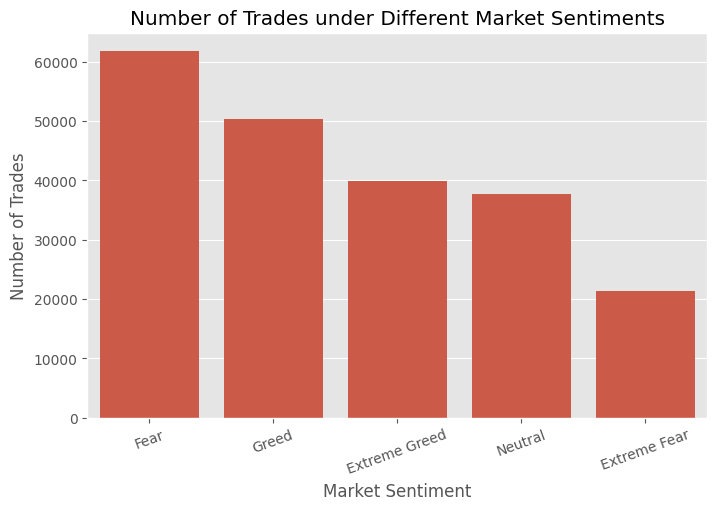

In [11]:
# ==========================================
# Trades by Market Sentiment
# ==========================================

plt.figure(figsize=(8,5))

sns.countplot(
    data=merged,
    x="classification",
    order=merged["classification"].value_counts().index
)

plt.title("Number of Trades under Different Market Sentiments")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.xticks(rotation=20)

plt.show()

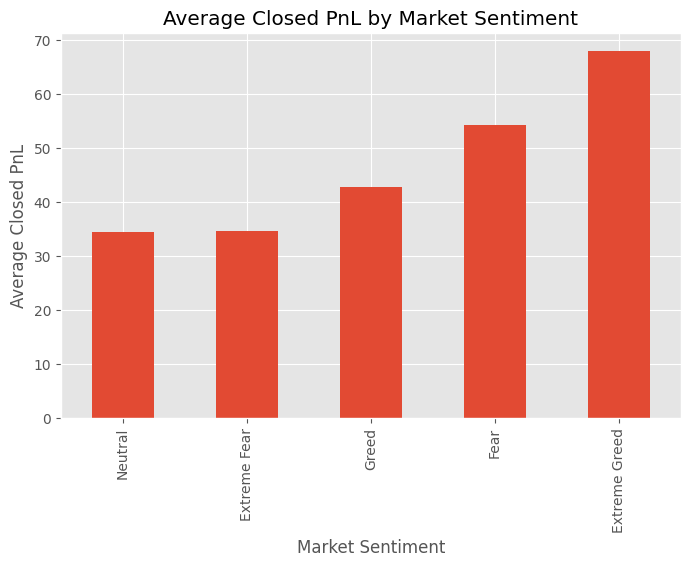

In [12]:
# ==========================================
# Average Closed PnL by Sentiment
# ==========================================

avg_pnl = merged.groupby("classification")["Closed PnL"].mean().sort_values()

plt.figure(figsize=(8,5))

avg_pnl.plot(kind="bar")

plt.title("Average Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")

plt.show()

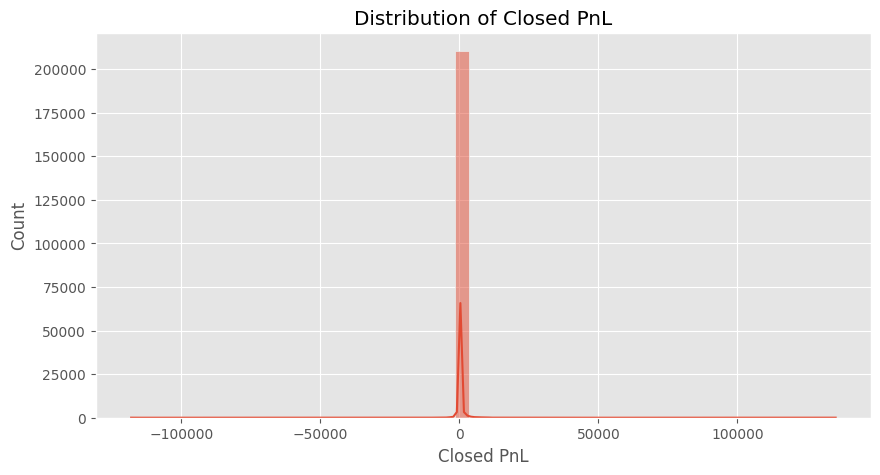

In [13]:
# ==========================================
# Closed PnL Distribution
# ==========================================

plt.figure(figsize=(10,5))

sns.histplot(
    merged["Closed PnL"],
    bins=50,
    kde=True
)

plt.title("Distribution of Closed PnL")

plt.show()

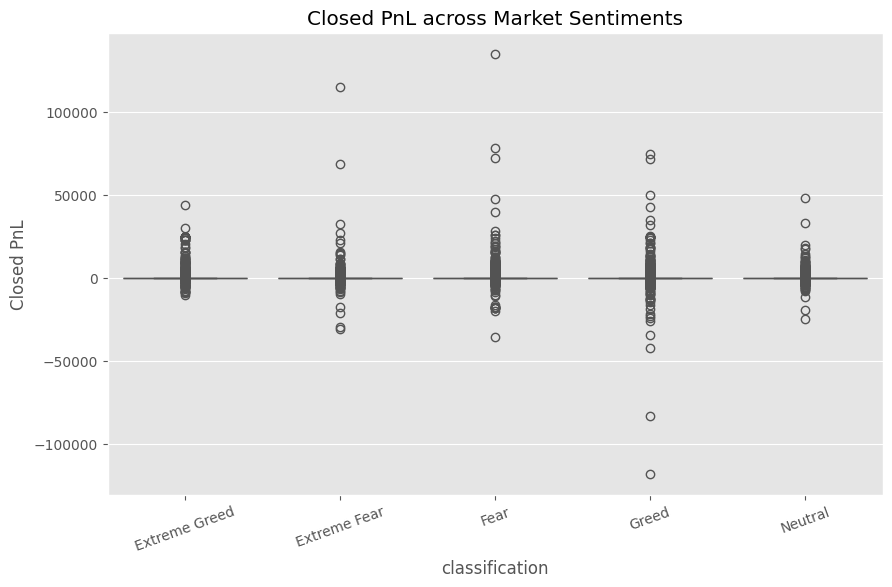

In [14]:
# ==========================================
# Closed PnL by Sentiment
# ==========================================

plt.figure(figsize=(10,6))

sns.boxplot(
    data=merged,
    x="classification",
    y="Closed PnL"
)

plt.title("Closed PnL across Market Sentiments")

plt.xticks(rotation=20)

plt.show()

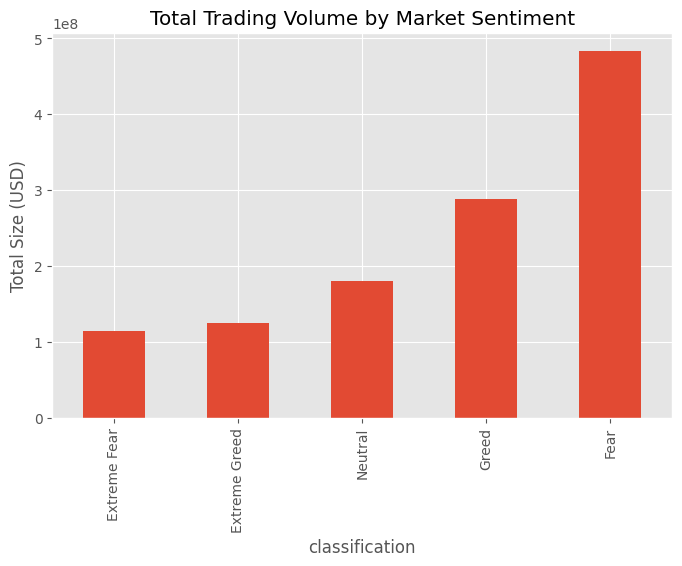

In [15]:
# ==========================================
# Trading Volume by Sentiment
# ==========================================

volume = merged.groupby("classification")["Size USD"].sum().sort_values()

plt.figure(figsize=(8,5))

volume.plot(kind="bar")

plt.title("Total Trading Volume by Market Sentiment")
plt.ylabel("Total Size (USD)")

plt.show()

## Statistical Analysis

In [16]:
# ==========================================
# T-Test
# ==========================================

fear = merged[merged["classification"]=="Fear"]["Closed PnL"].dropna()

greed = merged[merged["classification"]=="Greed"]["Closed PnL"].dropna()

t_stat, p_value = ttest_ind(fear, greed)

print("T Statistic :", t_stat)
print("P Value :", p_value)

T Statistic : 1.884727797757762
P Value : 0.05946918109970857


## Key Insights

### Insights

- Trading activity varies across different market sentiments.
- Average trader profitability changes depending on the Fear & Greed Index.
- Trading volume is generally higher during optimistic market conditions.
- The distribution of profits and losses contains significant outliers.
- Statistical testing helps determine whether differences between Fear and Greed are significant.

## Conclusion

This analysis explored the relationship between Bitcoin market sentiment and trader performance by combining historical trading data with the Fear & Greed Index.

The results indicate that market sentiment influences trading activity and profitability. These insights can help traders understand behavioral patterns and support more informed trading strategies.